In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

In [3]:
# wczytajmy przykładowe dane, tj. pliki z lokalizacji 00_dane, które odpowiadają przygotowanym w ramach poprzednich zajęć danych 'houses'
X_train = pd.read_csv('houses_X_train.csv')
X_test = pd.read_csv('houses_X_test.csv')
y_train = pd.read_csv('houses_y_train.csv')
y_test = pd.read_csv('houses_y_test.csv')

# rzut oka na pierwsze pięć wierszy tabeli opisującej przygotowane do analiz dane treningowe
X_train.head()

,Order,PID,Lot_Frontage,Lot_Area,Lot_Shape,Land_Contour,Utilities,Land_Slope,Overall_Qual,Overall_Cond,...,Misc_Feature_Othr,Misc_Feature_Shed,Misc_Feature_nan,Sale_Type_New,Sale_Type_Other,Sale_Type_WD,Sale_Condition_Family,Sale_Condition_Normal,Sale_Condition_Other,Sale_Condition_Partial
0,919,909257050,53,10918,3.0,3.0,2.0,2.0,6.0,8.0,...,0,0,1,0,0,1,0,1,0,0
1,1244,535180100,75,9464,3.0,3.0,2.0,2.0,5.0,6.0,...,0,0,1,0,0,1,0,1,0,0
2,1607,923277080,60,6600,3.0,3.0,2.0,2.0,4.0,5.0,...,0,0,1,0,0,1,0,1,0,0
3,1930,535300040,75,10050,3.0,3.0,2.0,2.0,4.0,4.0,...,0,0,1,0,0,1,0,1,0,0
4,1927,535180030,72,10152,3.0,3.0,2.0,2.0,4.0,4.0,...,0,0,1,0,0,1,0,1,0,0


In [4]:
X= sm.add_constant(X_train)  # dodajemy stałą do modelu
model = sm.OLS(y_train, X).fit()  # dopasowujemy model

In [5]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Sale_Price   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     113.4
Date:                Sun, 18 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:13:34   Log-Likelihood:                -27134.
No. Observations:                2344   AIC:                         5.460e+04
Df Residuals:                    2176   BIC:                         5.557e+04
Df Model:                         167                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [8]:
daneusa= pd.read_csv('daneusa_wstepnie_przygotowane.csv')
daneusa.head()

,UMARSTAT,UCUREMP,UCURNINS,USATMED,URELATE,REGION,STATE,HHID,FHOSP,FDENT,...,HOTHVAL,HRETVAL,HSSVAL,HWSVAL,UBRACE,GENDER,UEDUC3,CEYES,CHAIR,BIRTHDATE
0,Never married,No,Yes,Very satisfied,2,Midwest,WI,55616128,No,0,...,0,0,0,0,White,Female,No HS diploma or GED,hazel,brown,10/24/1993
1,Separated,Yes,No,Very satisfied,2,Midwest,WI,54704000,No,2,...,5950,0,0,31468,White,Female,"HS diploma or GED, no bachelor's degree",blue,black,6/13/1985
2,Married_live together,No,No,Very satisfied,5,Midwest,WI,57874272,No,0,...,11340,0,4920,24700,White,Male,No HS diploma or GED,brown,brown,11/15/1982
3,Divorced,No,Yes,Little dissatisfied,4,Midwest,WI,54106816,No,0,...,39002,0,0,60000,Black,Female,No HS diploma or GED,brown,black,6/25/1974
4,Never married,Yes,No,Very satisfied,0,Midwest,WI,54569152,No,2,...,4200,0,0,55280,Black,Male,"HS diploma or GED, no bachelor's degree",brown,black,2/27/1981


In [11]:
X= daneusa.drop(columns=['U_USHRS'])
y= daneusa['U_USHRS']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=pd.cut(y, bins=10, labels=False ))

In [18]:

DANEUSA_ZMIENNE_ILOSCIOWE = [
    'FDOCT','UAGE','U_WKSLY','U_HRSLY',
]

X= sm.add_constant(X_train[DANEUSA_ZMIENNE_ILOSCIOWE])  # dodajemy stałą do modelu
model = sm.OLS(y_train, X).fit()  # dopasowujemy model  
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                U_USHRS   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                 2.652e+04
Date:                Sun, 18 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:25:44   Log-Likelihood:                -89551.
No. Observations:               28057   AIC:                         1.791e+05
Df Residuals:                   28052   BIC:                         1.792e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4402      0.210     21.100      0.0

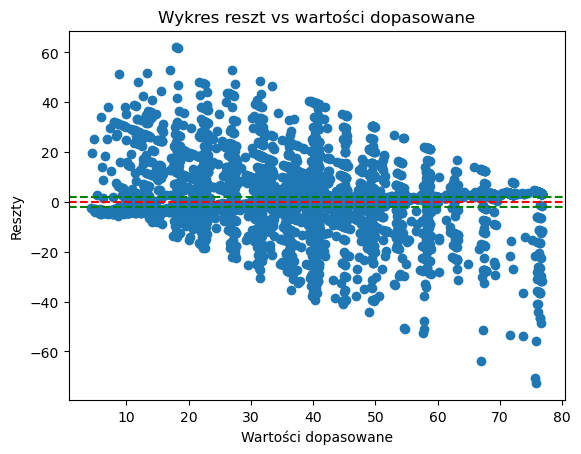

In [29]:
wartoci_dopasowane = model.fittedvalues
residuals = y_train - wartoci_dopasowane
plt.scatter(wartoci_dopasowane, residuals)
plt.axhline(y=0, color='r', linestyle='--') 
plt.axhline(y=2, color='g', linestyle='--')
plt.axhline(y=-2, color='g', linestyle='--')
plt.xlabel('Wartości dopasowane')
plt.ylabel('Reszty')
plt.title('Wykres reszt vs wartości dopasowane')
plt.show()

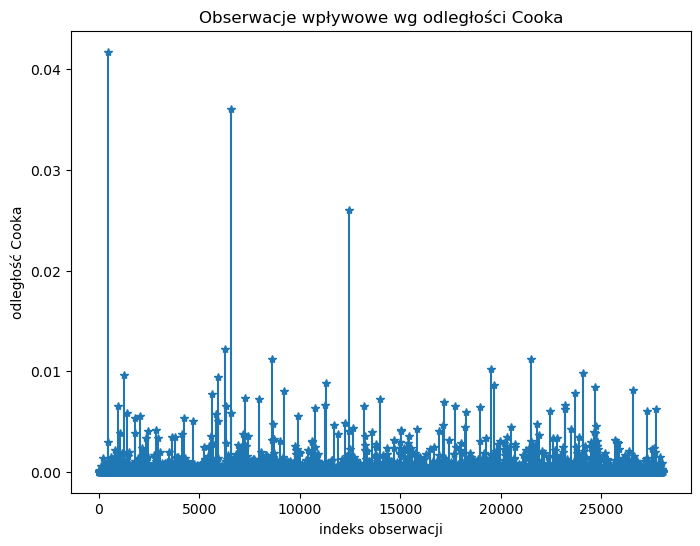

In [33]:
# odległości Cook'a
fitted_vals = model.fittedvalues

# uzyskiwanie reszt i ich wystandaryzowanie
influence = model.get_influence()
std_residuals = influence.resid_studentized_internal

# odległości Cook'a
cooks_d = influence.cooks_distance[0]

# wykres odległości Cook'a
plt.figure(figsize=(8, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt="*", basefmt=" ")
plt.xlabel('indeks obserwacji')
plt.ylabel('odległość Cooka')
plt.title('Obserwacje wpływowe wg odległości Cooka')
plt.show()

In [34]:
model.params

const      4.440249
FDOCT     -0.030420
UAGE      -0.017839
U_WKSLY    0.021985
U_HRSLY    0.894233
dtype: float64

In [35]:
model.bse

const      0.210440
FDOCT      0.009706
UAGE       0.003159
U_WKSLY    0.003708
U_HRSLY    0.002837
dtype: float64

In [36]:
model.tvalues

const       21.099865
FDOCT       -3.134301
UAGE        -5.646508
U_WKSLY      5.929006
U_HRSLY    315.229990
dtype: float64

In [37]:
model.pvalues

const      4.616817e-98
FDOCT      1.724415e-03
UAGE       1.653216e-08
U_WKSLY    3.083366e-09
U_HRSLY    0.000000e+00
dtype: float64

count    35072.000000
mean        41.521613
std         12.868015
min          1.000000
25%         39.000000
50%         40.000000
75%         50.000000
max         80.000000
Name: U_USHRS, dtype: float64
int64


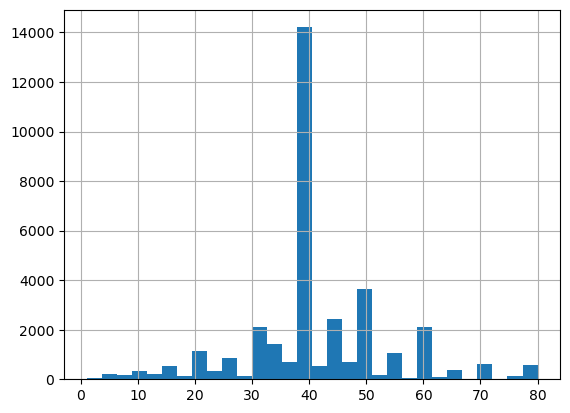

In [43]:
print(y.describe())
print(y.dtype)
y.hist(bins=30)
plt.show()

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [48]:
X = X_train[[
    'FDOCT','UAGE','U_WKSLY','U_HRSLY',
]]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data['Zmienna'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

   Zmienna        VIF
0    const  35.841404
1    FDOCT   1.007121
2     UAGE   1.038022
3  U_WKSLY   1.082557
4  U_HRSLY   1.060298
